Loading data from ../samples.txt (streaming mode)...
Scale factor: 2^16 = 65536
Total samples loaded: 1000000
Empirical Sigma (std dev): 7.63e+22 = 2^76.02
Actual Maximum Magnitude Sampled: 2.42e+23 = 2^77.68
Max Value as multiple of Sigma: 3.18 * sigma


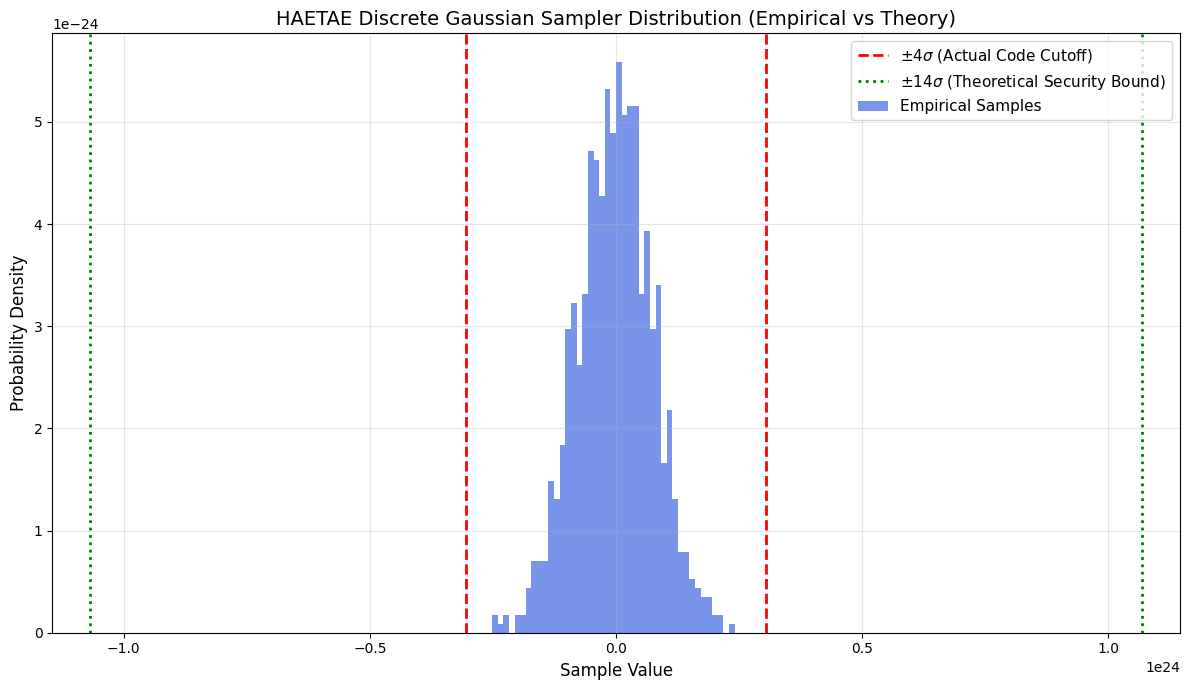

In [2]:
import math
import matplotlib.pyplot as plt
import numpy as np

# 读取 C 代码生成的样本数据（大样本量下采用流式处理，避免内存崩溃）
filename = '../samples.txt'
SCALE = 1 << 16          # 补偿采样实现中的16位右移
CHUNK_SIZE = 1_000_000   # 每次处理100万行，可按内存调大/调小
NUM_BINS = 200

print(f"Loading data from {filename} (streaming mode)...")
print(f"Scale factor: 2^16 = {SCALE}")

# ---------- 第一遍：流式计算 count / mean / std / max ----------
count = 0
mean = 0.0
M2 = 0.0
actual_max = 0

chunk_vals = []
with open(filename, 'r') as f:
    for line in f:
        s = line.strip()
        if not s:
            continue
        # 用 Python int（任意精度）读取，保证整数不会溢出
        v = int(s) * SCALE
        chunk_vals.append(float(v))

        av = abs(v)
        if av > actual_max:
            actual_max = av

        if len(chunk_vals) >= CHUNK_SIZE:
            arr = np.array(chunk_vals, dtype=np.float64)
            n = arr.size
            if n > 0:
                chunk_mean = float(arr.mean())
                chunk_M2 = float(((arr - chunk_mean) ** 2).sum())

                if count == 0:
                    mean = chunk_mean
                    M2 = chunk_M2
                    count = n
                else:
                    delta = chunk_mean - mean
                    new_count = count + n
                    mean = mean + delta * n / new_count
                    M2 = M2 + chunk_M2 + delta * delta * count * n / new_count
                    count = new_count
            chunk_vals.clear()

# 处理最后不足一个 chunk 的数据
if chunk_vals:
    arr = np.array(chunk_vals, dtype=np.float64)
    n = arr.size
    chunk_mean = float(arr.mean())
    chunk_M2 = float(((arr - chunk_mean) ** 2).sum())

    if count == 0:
        mean = chunk_mean
        M2 = chunk_M2
        count = n
    else:
        delta = chunk_mean - mean
        new_count = count + n
        mean = mean + delta * n / new_count
        M2 = M2 + chunk_M2 + delta * delta * count * n / new_count
        count = new_count

if count == 0:
    raise ValueError('No valid samples loaded from file.')

empirical_sigma = math.sqrt(M2 / count)

print(f"Total samples loaded: {count}")
print(f"Empirical Sigma (std dev): {empirical_sigma:.2e} = 2^{math.log2(empirical_sigma):.2f}")
print(f"Actual Maximum Magnitude Sampled: {float(actual_max):.2e} = 2^{math.log2(float(actual_max)):.2f}")
print(f"Max Value as multiple of Sigma: {float(actual_max) / empirical_sigma:.2f} * sigma")

# ---------- 第二遍：流式构建直方图（不保存全量样本） ----------
x_left = -15 * empirical_sigma
x_right = 15 * empirical_sigma
bin_edges = np.linspace(x_left, x_right, NUM_BINS + 1)
counts = np.zeros(NUM_BINS, dtype=np.int64)

chunk_vals = []
with open(filename, 'r') as f:
    for line in f:
        s = line.strip()
        if not s:
            continue
        v = int(s) * SCALE
        chunk_vals.append(float(v))

        if len(chunk_vals) >= CHUNK_SIZE:
            arr = np.array(chunk_vals, dtype=np.float64)
            counts += np.histogram(arr, bins=bin_edges)[0]
            chunk_vals.clear()

if chunk_vals:
    arr = np.array(chunk_vals, dtype=np.float64)
    counts += np.histogram(arr, bins=bin_edges)[0]

# 转成概率密度（与 plt.hist(..., density=True) 一致）
bin_width = bin_edges[1] - bin_edges[0]
density = counts / (count * bin_width)
centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# ---------- 绘图 ----------
plt.figure(figsize=(12, 7))
plt.bar(centers, density, width=bin_width, alpha=0.7, color='royalblue', label='Empirical Samples')

plt.axvline(4 * empirical_sigma, color='red', linestyle='dashed', linewidth=2, label=r'$\pm 4\sigma$ (Actual Code Cutoff)')
plt.axvline(-4 * empirical_sigma, color='red', linestyle='dashed', linewidth=2)

plt.axvline(14 * empirical_sigma, color='green', linestyle='dotted', linewidth=2, label=r'$\pm 14\sigma$ (Theoretical Security Bound)')
plt.axvline(-14 * empirical_sigma, color='green', linestyle='dotted', linewidth=2)

plt.title('HAETAE Discrete Gaussian Sampler Distribution (Empirical vs Theory)', fontsize=14)
plt.xlabel('Sample Value', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim(x_left, x_right)
plt.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))

plt.tight_layout()
plt.show()